# DNAscape tests

## Imports and configuration

In [1]:
#%run DNAscape_v0.0.9.ipynb

In [1]:
from dnascape import *

## Examples

### Quickstart

In [2]:
timedata = loadcsv('example', example='replication_timing_hESC', chr_number=1)

FileNotFoundError: [Errno 2] No such file or directory: 'data/example/replication_timing_hESC.csv'

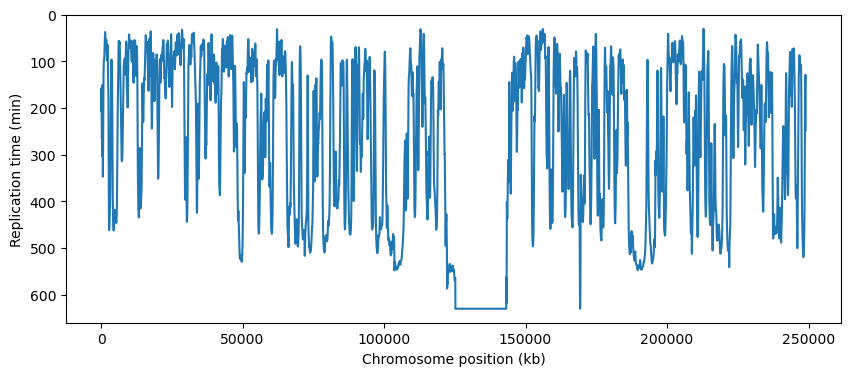

In [4]:
plotf(timedata, xtitle='Chromosome position (kb)', ytitle='Replication time (min)', invyQ=True, saveQ=True, sname='quick1', ext='png')

In [5]:
frates = rfit('replication_timing', 'firing_rate', source=timedata)

[10/10]  Elapsed: 00:03:06  ETA: 00:00:00  MSE: 7.8647e+02

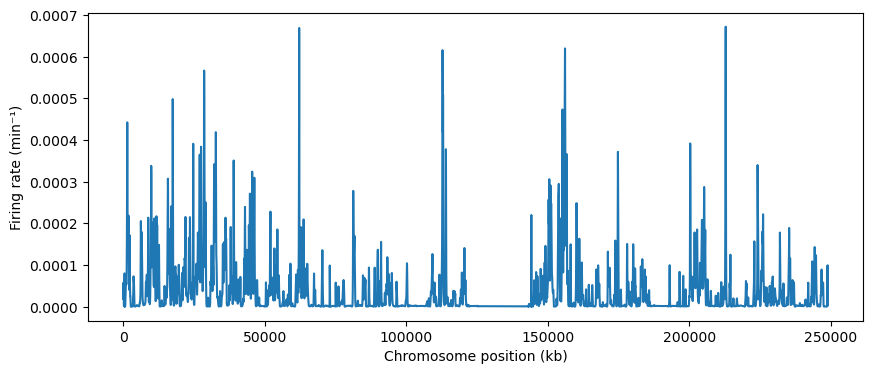

In [6]:
plotf(frates, xtitle='Chromosome position (kb)', ytitle='Firing rate (min⁻¹)')

In [7]:
timepred = rfit('firing_rate', 'replication_timing', source=frates)

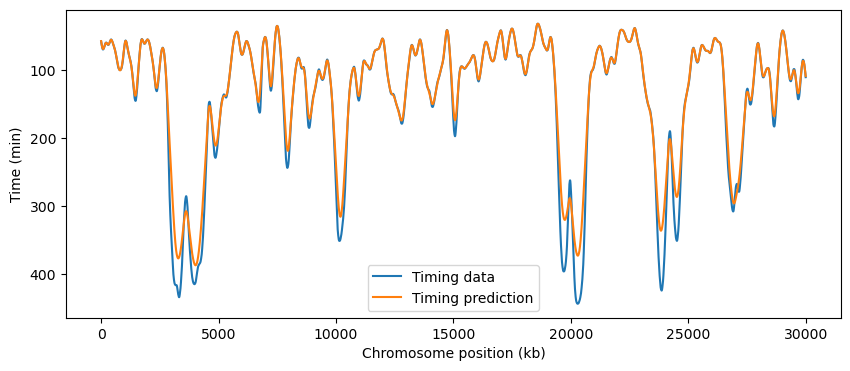

In [8]:
plotf(timedata[10000:40000], timepred[10000:40000],
      labels=['Timing data', 'Timing prediction'], xtitle='Chromosome position (kb)', ytitle='Time (min)', invyQ=True)

In [9]:
simres = rsim(frates, time_statsQ=True, sim_number=100)

[100/100]  Elapsed: 00:03:02  ETA: 00:00:00

In [10]:
timesim = simres['replication_timing']
iod = simres['inter_ori_distances']
frep = simres['fraction_replicated']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']

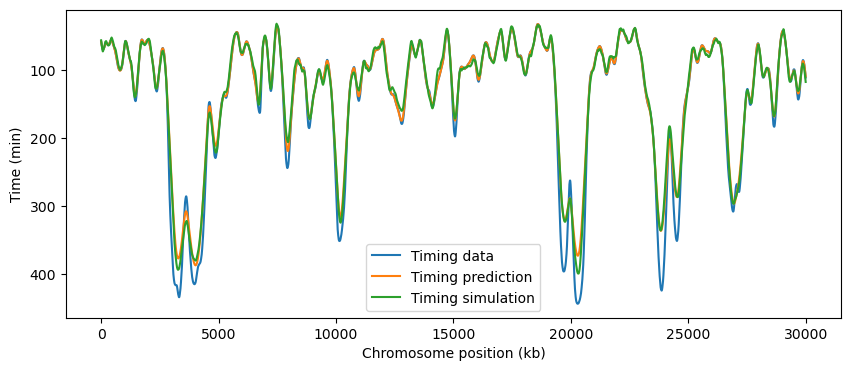

In [11]:
plotf(timedata[10000:40000], timepred[10000:40000], timesim[10000:40000],
      labels=['Timing data', 'Timing prediction', 'Timing simulation'], xtitle='Chromosome position (kb)', ytitle='Time (min)', invyQ=True)

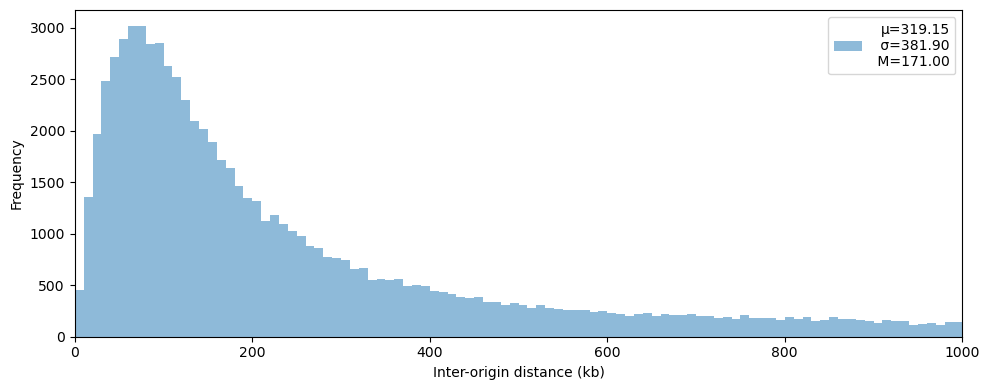

In [12]:
ploth(iod, xtitle='Inter-origin distance (kb)', bin_size=10, xmax=1000)

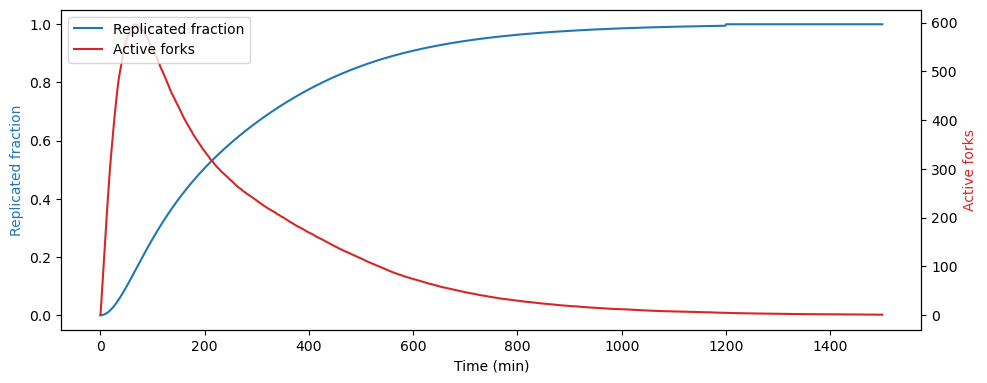

(<Figure size 1000x400 with 2 Axes>,
 (<Axes: xlabel='Time (min)', ylabel='Replicated fraction'>,
  <Axes: ylabel='Active forks'>))

In [13]:
plotf(frep, forka, xtitle='Time (min)', labels=['Replicated fraction','Active forks'], dual_axis=True)

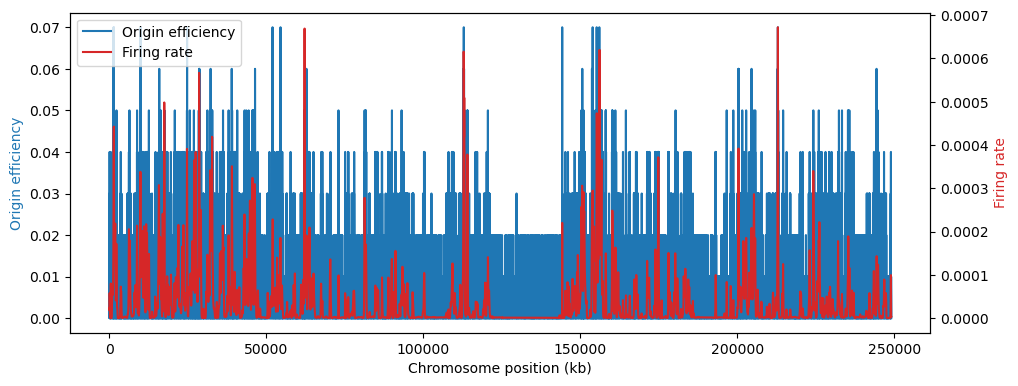

(<Figure size 1000x400 with 2 Axes>,
 (<Axes: xlabel='Chromosome position (kb)', ylabel='Origin efficiency'>,
  <Axes: ylabel='Firing rate'>))

In [14]:
plotf(effic, frates, xtitle='Chromosome position (kb)', labels=['Origin efficiency','Firing rate'], dual_axis=True)

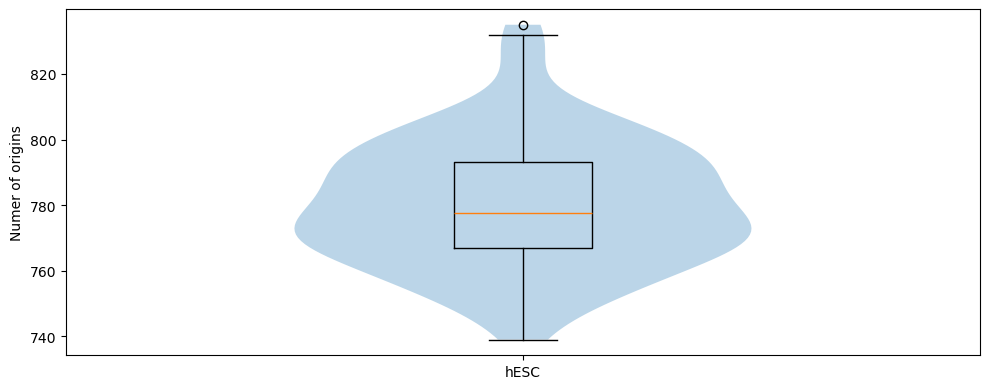

In [15]:
plotw(nroris, ytitle='Numer of origins', labels=['hESC'], violinQ=True)

In [16]:
nroris_dict = {}
for chr_number in range(1,23):
    fratesdata = loadcsv('example', example='firing_rate_hESC', chr_number=chr_number)
    simres = rsim(fratesdata, time_statsQ=True, sim_number=100)
    nroris_dict[chr_number] = simres['num_oris']

[100/100]  Elapsed: 00:00:22  ETA: 00:00:00

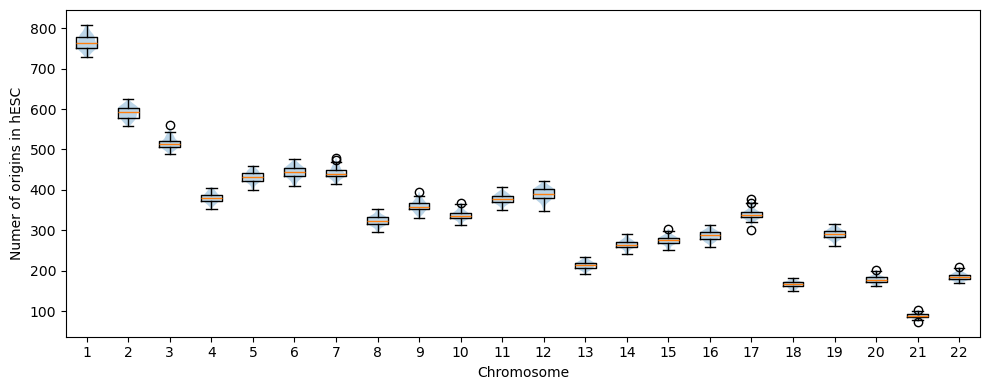

In [17]:
plotw(*nroris_dict.values(), xtitle='Chromosome', ytitle='Numer of origins in hESC', labels=[f'{nr}' for nr in range(1,23)], violinQ=True)

### Neater examples

In [139]:
timedata = loadcsv('example', example='replication_timing_Pl', chr_number=1)
timedata = rescale(timedata, [0, 60])
frates = rfit('replication_timing', 'firing_rate', source=timedata, fork_speed=0.6, maxiter=10, resolution=5, perQ=True, stall_rate=0., save_errQ=True)

[10/10]  Elapsed: 00:00:00  ETA: 00:00:00  MSE: 2.2829e-01

In [140]:
simres = rsim(frates, time_statsQ=True, fork_speed=0.6, sim_number=1, perQ=True, stall_rate=0.1)
timesim = simres['replication_timing']

[1/1]  Elapsed: 00:00:00  ETA: 00:00:00

In [145]:
effic = simres['efficiency']

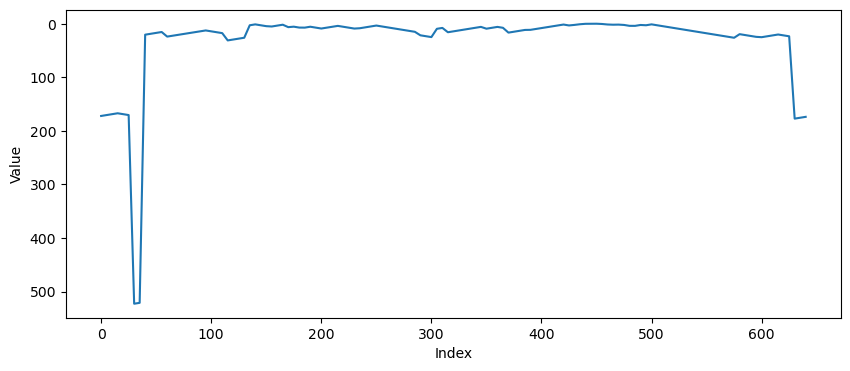

In [141]:
plotf(timesim, invyQ=True, resolution=5)

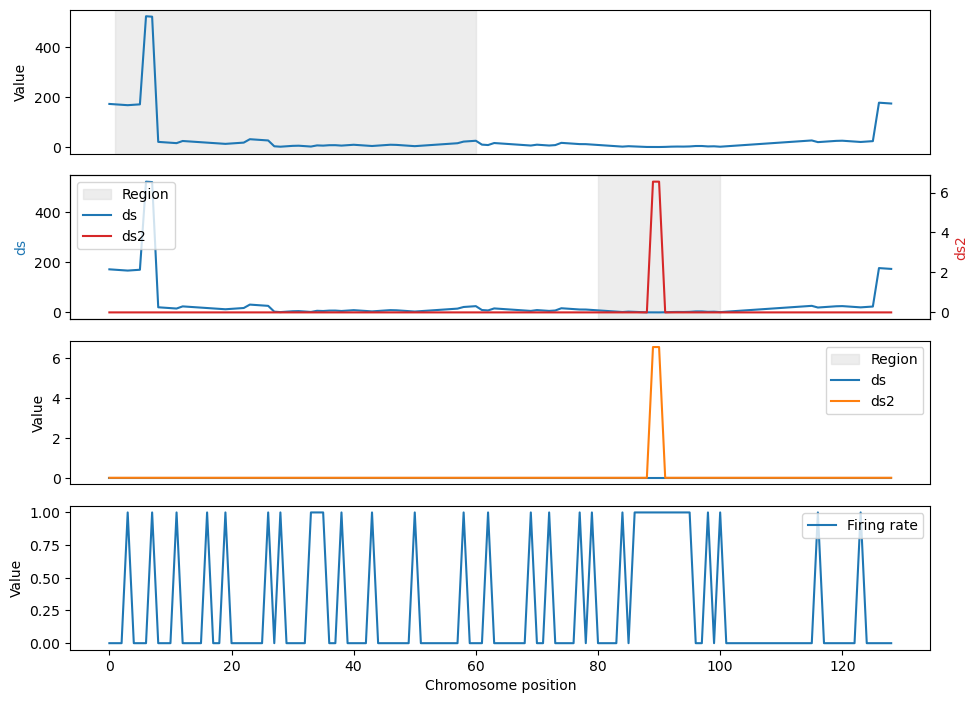

In [213]:
mplotf([timesim, [timesim,frates], [timesim,frates], effic], 
       figsize=(10,2), mregion_high=[range(1,60),range(80,100), range(800,900)], mxtitle='Chromosome position',
       mlabels=[None,['ds','ds2'], ['ds','ds2'],['Firing rate']], mdual_axis=[False, True,False,False])

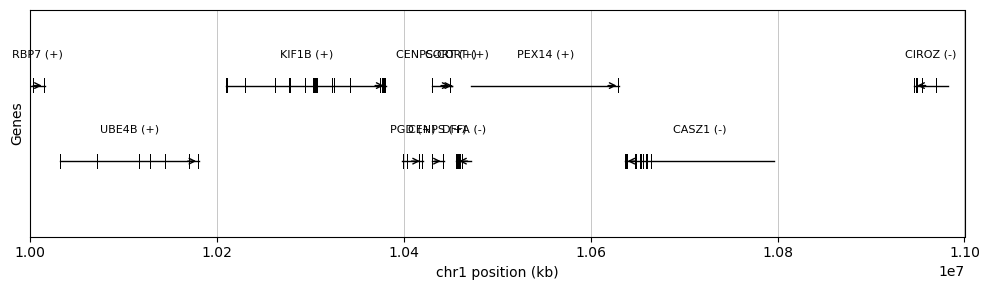

In [4]:
# ---- Example usage ----
gtf_path = "data/other/gencode/gencode.v49.annotation.gtf.gz"
chrom = "chr1"
start = 10_000_000
end   = 11_000_000

genes = load_gene_models_from_gtf_gz(
    gtf_path, chrom, start, end,
    keep_gene_types="protein_coding",  # e.g. {"protein_coding"} if you want
    max_genes=20
)

ax = plot_gene_track(genes, chrom, start, end, show_direction=True, show_names=True, denseQ=True)
plt.tight_layout()
plt.show()

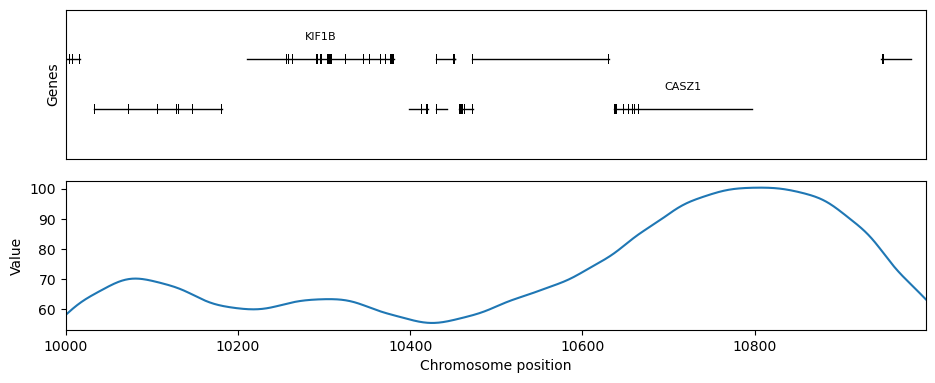

In [3]:
region = range(10000,11000)
mplotf([timedata[region]], mx_array=[[region]], 
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=True)

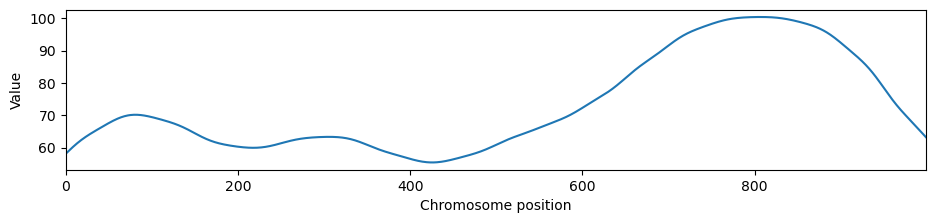

In [259]:
mplotf([timedata[10000:11000]],
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=False)

In [36]:
simres = rsim(frates, time_statsQ=True, sim_number=1)

[1/1]  Elapsed: 00:00:01  ETA: 00:00:00

In [37]:
timesim = simres['replication_timing']
iod = simres['inter_ori_distances']
frep = simres['fraction_replicated']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']
rfd = simres['fork_directionality']

In [13]:
simres.keys()

dict_keys(['replication_timing', 'num_oris', 'inter_ori_distances', 'rep_times_per_sim', 'efficiency', 's_phase_duration', 'time_grid', 'fraction_replicated', 'total_forks', 'active_forks', 'stalled_forks', 'firing_factors'])

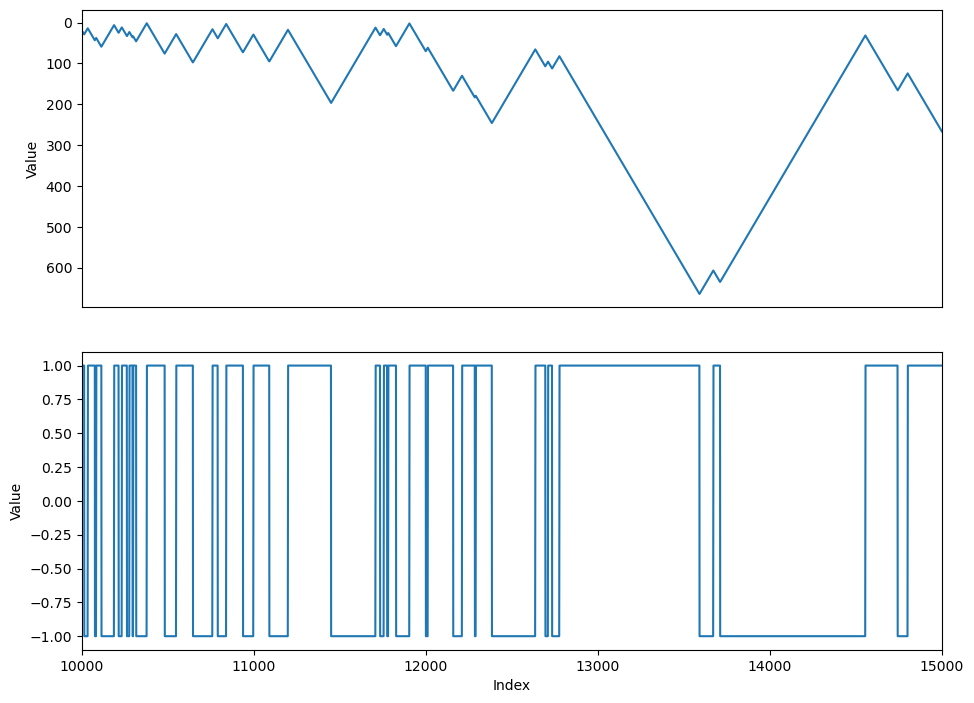

In [38]:
region = range(10000,15001)
mplotf([timesim[region], rfd[region]], minvyQ=[True], mx_array=[[region], [region]])